# Reinforcement Learning - Pekiştirmeli Öğretim

In [1]:
'''
import warnings
warnings.fiterwarnings('ignore')
'''

"\nimport warnings\nwarnings.fiterwarnings('ignore')\n"

In [2]:
#pip install gym

In [3]:
#pip install gymnasium

In [4]:
import gymnasium as gym

In [5]:
env = gym.make('FrozenLake-v1', is_slippery = False,render_mode = 'rgb_array')

In [6]:
import matplotlib.pyplot as plt

In [7]:
#pip install "gymnasium[toy-text]"

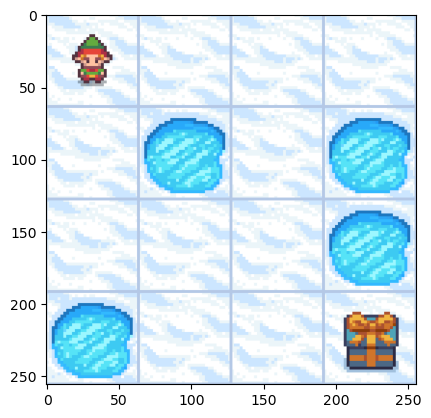

In [8]:
state = env.reset()
img = env.render()
plt.imshow(img)

In [9]:
action = env.action_space.sample()

In [10]:
next_state, reward , terminated , truncated, info = env.step(action)

In [11]:
print(next_state, reward , terminated , truncated, info)

1 0.0 False False {'prob': 1.0}


In [12]:
import numpy as np
import gymnasium as gym
import pickle

env=gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
state_size=env.observation_space.n
action_size=env.action_space.n
Q_table=np.zeros((state_size,action_size))

alpha=0.1 # Learning rate
gamma=0.99 # discount factor
epsilon=1.0 # Exploration Rate
epsilon_decay=0.995 #
epsilon_min=0.01
episodes=2000

for episode in range(episodes):
    state=env.reset()[0] #reset the environment
    done = False

    while not done:
        if np.random.rand()<epsilon:
            action=env.action_space.sample() #exploration
        else:
            action=np.argmax(Q_table[state])
            
        next_state,reward,terminated,truncated,info=env.step(action)

        Q_table[state,action]+=alpha*(reward+gamma*np.max(Q_table[next_state])-Q_table[state,action])

        state=next_state
        
        done=terminated or truncated
        
    epsilon=max(epsilon*epsilon_decay,epsilon_min)
with open('qtable_fl.pkl','wb') as f:
    pickle.dump(Q_table,f)
print('training completed and model saved')
env.close()



training completed and model saved


In [17]:
np.save('frozenlake.npy',Q_table)

In [18]:
print(Q_table) # öğrendiği tecrübeyi kaydettiği tablo

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [19]:
import seaborn as sns

<Axes: >

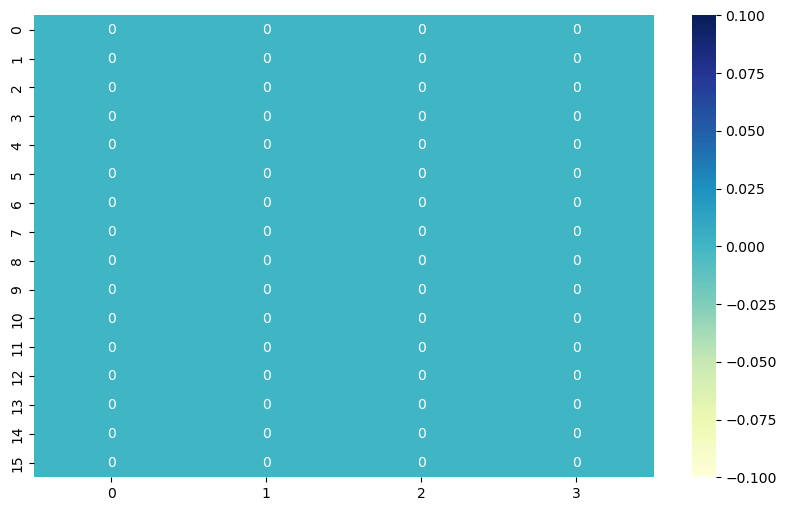

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(Q_table, annot=True, cmap='YlGnBu')

In [21]:
import numpy as np
import gymnasium as gym
import time

env=gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

state,_ =env.reset()
done=False
total_reward=0

while not done:
    time.sleep(0.5)
    action=np.argmax(Q_table[state])
    state,reward,terminated,truncated,info=env.step(action)
    done=terminated or truncated
    total_reward+=reward

env.close()
print('total reward: ',total_reward)

total reward:  0.0


# Bellman Equation

In [22]:
import numpy as np
import gymnasium as gym

# Create and unwrap FrozenLake environment to access .P
env = gym.make("FrozenLake-v1", is_slippery=False)
env = env.unwrapped

state_size = env.observation_space.n
action_size = env.action_space.n

V = np.zeros(state_size)
gamma = 0.9
theta = 1e-4  # Stopping threshold

def one_step_lookahead(state, V):
    A = np.zeros(action_size)
    for a in range(action_size):
        for prob, next_state, reward, done in env.P[state][a]:
            A[a] += prob * (reward + gamma * V[next_state])
    return A

iteration = 0
while True:
    delta = 0
    for s in range(state_size):
        A = one_step_lookahead(s, V)
        best_action_value = np.max(A)
        delta = max(delta, np.abs(best_action_value - V[s]))
        V[s] = best_action_value
    iteration += 1
    if delta < theta:
        break

print(f"Final value function after {iteration} iterations:\n")
print(np.round(V.reshape(4, 4), 2))

Final value function after 7 iterations:

[[0.59 0.66 0.73 0.66]
 [0.66 0.   0.81 0.  ]
 [0.73 0.81 0.9  0.  ]
 [0.   0.9  1.   0.  ]]


# Value Iteration

In [23]:
import numpy as np
import gymnasium as gym
# Create and unwrap FrozenLake environment to access .P
env = gym.make("FrozenLake-v1", is_slippery=False)
env = env.unwrapped
state_size = env.observation_space.n
action_size = env.action_space.n
V = np.zeros(state_size)
gamma = 0.9
theta = 1e-4  # Stopping threshold
def one_step_lookahead(state, V):
    A = np.zeros(action_size)
    for a in range(action_size):
        for prob, next_state, reward, done in env.P[state][a]:
            A[a] += prob * (reward + gamma * V[next_state])
    return A
iteration = 0
while True:
    delta = 0
    for s in range(state_size):
        A = one_step_lookahead(s, V)
        best_action_value = np.max(A)
        delta = max(delta, np.abs(best_action_value - V[s]))
        V[s] = best_action_value
    iteration += 1
    if delta < theta:
        break
print(f"Final value function after {iteration} iterations:\n")
print(np.round(V.reshape(4, 4), 2))

Final value function after 7 iterations:

[[0.59 0.66 0.73 0.66]
 [0.66 0.   0.81 0.  ]
 [0.73 0.81 0.9  0.  ]
 [0.   0.9  1.   0.  ]]


# Deep Learning DQN

In [24]:
##################################################### Kodlar Colabta

In [ ]:
####################################################

In [25]:
env=gym.make("CartPole-v1", render_mode="rgb_array")